In [1]:
import os
import sys
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import time
import scipy
import scipy.sparse as sp
from scipy.sparse import csr_matrix
import anndata as an
from collections import Counter
import matplotlib.pyplot as plt
import random
from importlib import reload
import warnings
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import issparse
from matplotlib.collections import LineCollection
from itertools import chain
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import pickle as pkl
from pastis import optimization


"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

/home/jduhamel/.conda/envs/pore_c_3d/lib/python3.12/site-packages/iced/normalization/_ca_utils.py:8: UserWarning: The API of this module is likely to change. Use only for testing purposes
  warnings.warn(
/home/jduhamel/pastis/pastis/fastio.py:7: UserWarning: The module pastis.fastio is deprecated. The packaged iced has identical features and should be used instead. This module will be removed in version 0.5
  warnings.warn(


In [2]:
# # Read in core incidence
# path_clean = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_100000_core.h5ad"

# start_time = time.time()  # Record the start time
# cdata = sc.read_h5ad(path_clean)
# end_time = time.time()  # Record the end time
# print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
# sc.logging.print_memory_usage()

In [3]:
H_cell_file = open("/home/jduhamel/sc_pore_c/notebooks/distribution/cells/H_cell_o3b82.pkl", "rb")
H_cell = pkl.load(H_cell_file)

H_cell.head()

,o3b82_ea44bd58-3f19-5a79-88fa-983545deeb9b,o3b82_9ff53864-f712-4cc6-ac30-3f70d3a48f1e,o3b82_88a250c0-9c9c-4ad6-81a9-1e1fdfd4c4a2_2,o3b82_a35e4e06-240f-460f-ac24-7913ff729eea,o3b82_ed71a1da-ecea-4b03-ab76-4daf5314a29e,o3b82_d55823ff-0576-474b-a87f-8206c0c25ecf,o3b82_5e679fb2-0206-40ee-b5a2-a0dea6895209,o3b82_b0ab1931-aa92-414d-a28d-59775333eaea,o3b82_16549b7c-9198-47fd-8e81-42f96d92b14a,o3b82_059c6af3-60d4-49f6-bff8-2e5874afb465,...,o3b82_fad64ca3-23db-4a08-bed4-818252061a4c,o3b82_29a5be84-34db-47b6-b3ee-db30d2106921,o3b82_aad62ee8-7d39-4570-a171-917c1577fa60,o3b82_3c927481-ce79-4a2b-9770-515abde16a07,o3b82_78f374c9-0013-4b9b-a887-55799d8ae0b9,o3b82_7d4215bd-2514-41d5-97df-888d7ba4c787,o3b82_f864f28e-ed91-4b72-ab6c-fb1757d87e84,o3b82_3be61cf1-4f1e-46b7-97cf-84eb2a41a6a9,o3b82_aeed7255-0fdb-4401-92e7-447ae3fa046f,o3b82_3eebd096-9bac-4df9-910f-e54adab73c96
bin_name,,,,,,,,,,,,,,,,,,,,,
chr4:130,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chr6:52,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chr1:86,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chrX:23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chr9:124,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
incidence = sp.csr_matrix(H_cell)
bin_names = H_cell.index
read_names = H_cell.columns

In [5]:
def build_pore_c_contact_matrix(incidence_matrix, bin_names, 
                                  min_contacts=2, cis_only=False):
    """
    Exploit PoreC multi-way contacts properly.
    For a read touching k bins, add 1 to all k*(k-1)/2 pairs.
    Optionally restrict to cis (same chromosome) contacts only.
    
    Parameters
    ----------
    incidence_matrix : sparse matrix, shape (n_reads, n_bins)
        Binary matrix where entry [i, j] = 1 if read i covers bin j.
    bin_names : list of str
        Bin labels like 'chr1:1000000-2000000', length must equal n_bins (columns).
    """
    n_reads, n_bins = incidence_matrix.shape
    
    # Validate dimensions
    if n_bins != len(bin_names):
        raise ValueError(
            f"Incidence matrix has {n_bins} columns but got {len(bin_names)} bin_names. "
            f"Matrix shape is {incidence_matrix.shape}. "
            f"You may need to transpose: incidence_matrix.T"
        )
    
    bin_chroms = [b.split(':')[0] for b in bin_names]
    
    # Convert to lil for efficient row access
    inc = incidence_matrix.tolil()
    contact_matrix = np.zeros((n_bins, n_bins))
    
    for read_idx in range(n_reads):
        # Bins touched by this read (column indices)
        touched = list(inc.rows[read_idx])
        
        if len(touched) < min_contacts:
            continue
        
        # All pairwise combinations from this concatemer
        for i in range(len(touched)):
            for j in range(i+1, len(touched)):
                b1, b2 = touched[i], touched[j]
                
                if cis_only:
                    if bin_chroms[b1] != bin_chroms[b2]:
                        continue
                
                contact_matrix[b1, b2] += 1
                contact_matrix[b2, b1] += 1
    
    return contact_matrix



In [6]:
print(f"Incidence matrix shape: {incidence.shape}")
print(f"Number of read names: {len(read_names)}")
print(f"Number of bin names: {len(bin_names)}")

# If shape is (n_bins, n_reads), transpose it:
if incidence.shape[0] == len(bin_names) and incidence.shape[1] == len(read_names):
    print("Transposing incidence matrix: was (bins x reads), converting to (reads x bins)")
    incidence = incidence.T

# Now call the function
contact_matrix = build_pore_c_contact_matrix(
    incidence, 
    bin_names,
    min_contacts=2,
    cis_only=False
)

Incidence matrix shape: (2579, 9885)
Number of read names: 9885
Number of bin names: 2579
Transposing incidence matrix: was (bins x reads), converting to (reads x bins)


In [7]:
def ice_normalisation(contact_matrix, max_iter=100, tolerance=1e-5):
    """
    Iterative Correction and Eigenvector decomposition (ICE)
    Removes systematic biases from bin mappability/GC content
    """
    matrix = contact_matrix.copy().astype(float)
    n = matrix.shape[0]
    
    # Remove bins with zero contacts
    coverage = matrix.sum(axis=1)
    valid_bins = coverage > 0
    
    bias = np.ones(n)
    
    for iteration in range(max_iter):
        # Row/column sums
        marginals = matrix.sum(axis=1)
        marginals[marginals == 0] = 1  # avoid division by zero
        
        # Normalise
        scale = np.sqrt(marginals)
        matrix = matrix / np.outer(scale, scale)
        bias *= scale
        
        # Check convergence
        new_marginals = matrix.sum(axis=1)
        new_marginals[~valid_bins] = 1
        
        if np.abs(new_marginals[valid_bins] - 1).max() < tolerance:
            print(f"ICE converged at iteration {iteration}")
            break
    
    return matrix, bias, valid_bins

normalised_matrix, bias, valid_bins = ice_normalisation(contact_matrix)

In [8]:
def contacts_to_distances(contact_matrix, beta=-0.33, pseudocount=1e-10):
    """
    Convert contact frequencies to spatial distances.
    d ~ f^beta, beta=-1/3 assumes a fractal globule polymer model
    which is appropriate for mammalian interphase chromatin.
    """
    matrix = contact_matrix.copy()
    
    # Add pseudocount to avoid zeros
    # Only where we have valid (non-zero row/col) entries
    valid = matrix.sum(axis=1) > 0
    matrix[valid][:, valid] += pseudocount
    
    # Convert: higher contact = shorter distance
    with np.errstate(divide='ignore', invalid='ignore'):
        dist = np.where(matrix > 0, np.power(matrix, beta), 0)
    
    # For bins with no contacts set distance to maximum
    max_dist = dist[dist > 0].max() if (dist > 0).any() else 1.0
    dist[dist == 0] = max_dist * 2
    
    np.fill_diagonal(dist, 0)
    
    # Ensure symmetry
    dist = (dist + dist.T) / 2
    
    return dist

dist_matrix = contacts_to_distances(normalised_matrix)

In [9]:
def calculate_3d_structure(contact_matrix, bin_names, 
                            valid_bins, alpha=3, random_state=42):
    """
    Use PASTIS MDS/NMDS for 3D genome structure inference.
    """
    from pastis import optimization
    
    # Work only with valid bins
    sub_matrix = contact_matrix[valid_bins][:, valid_bins]
    sub_bins = [b for b, v in zip(bin_names, valid_bins) if v]
    
    n_bins = sub_matrix.shape[0]
    print(f"Calculating structure for {n_bins} bins...")
    
    if hasattr(sub_matrix, 'toarray'):
        sub_matrix = sub_matrix.toarray()
    
    # MDS step
    mds = optimization.MDS(alpha=alpha, random_state=random_state)
    coords_mds = mds.fit(sub_matrix)
    
    # Ensure init is 1D for NMDS (PASTIS expects flattened n*3 vector)
    if isinstance(coords_mds, np.ndarray):
        init_flat = coords_mds.ravel()
    else:
        init_flat = None
    
    # NMDS step
    nmds = optimization.NMDS(alpha=alpha, random_state=random_state, init=init_flat)
    coords_nmds = nmds.fit(sub_matrix)
    
    # Ensure output is (n_bins, 3)
    if isinstance(coords_nmds, np.ndarray) and coords_nmds.ndim == 1:
        coords_nmds = coords_nmds.reshape(-1, 3)
    
    return coords_nmds, sub_bins

In [10]:
def calculate_ensemble(contact_matrix, bin_names, valid_bins, 
                       n_models=5, alpha=3):
    """
    Run structure calculation n times with different random seeds.
    Like the paper's 5 superimposed structures.
    """
    ensemble = []
    
    for i in range(n_models):
        print(f"Calculating model {i+1}/{n_models}...")
        coords, valid_bin_names = calculate_3d_structure(
            contact_matrix, bin_names, valid_bins,
            alpha=alpha, random_state=i*42
        )
        ensemble.append(coords)
    ensemble = np.array(ensemble)  # shape: (n_models, n_bins, 3)
    
    # Calculate RMSD between models as quality measure
    # (paper reports < 1.75 particle radii)
    rmsds = []
    for i in range(n_models):
        for j in range(i+1, n_models):
            diff = ensemble[i] - ensemble[j]
            rmsd = np.sqrt((diff**2).sum(axis=1).mean())
            rmsds.append(rmsd)
    
    print(f"Mean pairwise RMSD: {np.mean(rmsds):.3f}")
    print(f"Max pairwise RMSD:  {np.max(rmsds):.3f}")
    
    return ensemble, valid_bin_names

ensemble, valid_bin_names = calculate_ensemble(
    normalised_matrix, bin_names, valid_bins, n_models=5
)

Calculating model 1/5...
Calculating structure for 2420 bins...
writing wish distances
Calculating model 2/5...
Calculating structure for 2420 bins...
writing wish distances
Calculating model 3/5...
Calculating structure for 2420 bins...
writing wish distances
Calculating model 4/5...
Calculating structure for 2420 bins...
writing wish distances
Calculating model 5/5...
Calculating structure for 2420 bins...
writing wish distances
Mean pairwise RMSD: 1.053
Max pairwise RMSD:  1.071


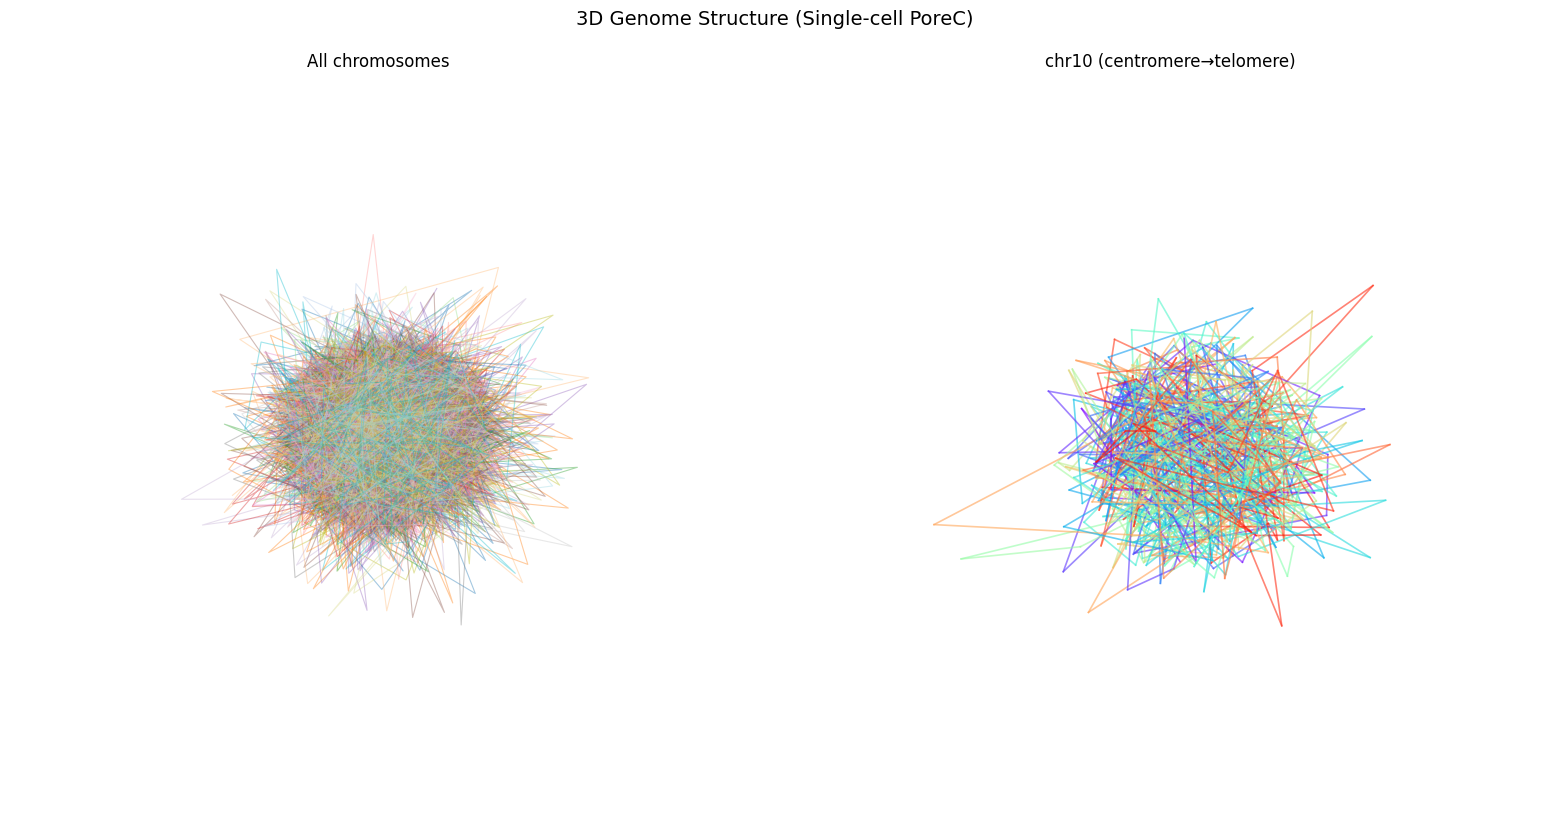

In [11]:
def plot_genome_structure(ensemble, bin_names, 
                          highlight_chrom=None, alpha=0.4):
    """
    Replicate Fig 1c style:
    - All chromosomes colored differently (main view)
    - Single chromosome colored red->purple centromere->telomere (inset)
    """
    chroms = list(dict.fromkeys([b.split(':')[0] for b in bin_names]))
    n_chroms = len(chroms)
    
    # Assign a distinct color per chromosome
    chrom_colors = cm.tab20(np.linspace(0, 1, n_chroms))
    color_map = {c: chrom_colors[i] for i, c in enumerate(chroms)}
    
    fig = plt.figure(figsize=(16, 8))
    
    # --- Main plot: all chromosomes ---
    ax1 = fig.add_subplot(121, projection='3d')
    
    for model_coords in ensemble:
        for chrom in chroms:
            # Get bins for this chromosome in genomic order
            mask = sorted(
                [i for i, b in enumerate(bin_names) 
                 if b.split(':')[0] == chrom],
                key=lambda i: int(bin_names[i].split(':')[1].split('-')[0])
            )
            if not mask:
                continue
                
            xyz = model_coords[mask]
            ax1.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2],
                    color=color_map[chrom],
                    alpha=alpha,
                    linewidth=0.8)
    
    ax1.set_title('All chromosomes', fontsize=12)
    ax1.set_axis_off()
    
    # --- Inset: single chromosome red->purple ---
    if highlight_chrom is None:
        highlight_chrom = chroms[0]
    
    ax2 = fig.add_subplot(122, projection='3d')
    
    chrom_mask = sorted(
        [i for i, b in enumerate(bin_names) 
         if b.split(':')[0] == highlight_chrom],
        key=lambda i: int(bin_names[i].split(':')[1].split('-')[0])
    )
    
    for model_coords in ensemble:
        xyz = model_coords[chrom_mask]
        n_points = len(xyz)
        
        # Color gradient red -> purple (centromere -> telomere)
        colors = cm.rainbow(np.linspace(0, 1, n_points))
        
        # Plot as colored segments
        for i in range(n_points - 1):
            ax2.plot(xyz[i:i+2, 0], xyz[i:i+2, 1], xyz[i:i+2, 2],
                    color=colors[i],
                    alpha=alpha + 0.2,
                    linewidth=1.2)
    
    ax2.set_title(f'{highlight_chrom} (centromere→telomere)', fontsize=12)
    ax2.set_axis_off()
    
    plt.suptitle('3D Genome Structure (Single-cell PoreC)', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('genome_3d_structure.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_genome_structure(
    ensemble, 
    valid_bin_names,
    highlight_chrom='chr10'  # or whichever you want in inset
)

In [ ]:
plotstructure(